In [56]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy -q

In [57]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kruskal, spearmanr

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 9,
    'figure.dpi'       : 150,
})

# ── Caminhos ────────────────────────────────────────────────────────────────
METRICS_PATH = '/content/dataset_metrics.csv'
SMELLS_PATH  = '/content/dataset_code_smells.csv'
OUTPUT_PATH  = '/content/dataset_clusterizado.csv'

# ── Parâmetros ───────────────────────────────────────────────────────────────
SEED         = 42
TSNE_SAMPLE  = 10_000

# ── Métricas estruturais para clustering ─────────────────────────────────────
METRIC_COLS = ['loc', 'wmc', 'cbo', 'rfc', 'lcom', 'fanin', 'fanout']

# ── Code smells (usados somente após clustering) ─────────────────────────────
SMELL_COLS = [
    'BrainMethod', 'ClassDataShouldBePrivate', 'ComplexClass', 'DataClass',
    'DispersedCoupling', 'FeatureEnvy', 'GodClass', 'IntensiveCoupling',
    'LazyClass', 'LongMethod', 'LongParameterList', 'MessageChain',
    'RefusedBequest', 'ShotgunSurgery', 'SpaghettiCode', 'SpeculativeGenerality',
]
SMELL_SHORT = {
    'BrainMethod':'BrainMeth',      'ClassDataShouldBePrivate':'CDPrivate',
    'ComplexClass':'Complex',        'DataClass':'DataCls',
    'DispersedCoupling':'DispCoup',  'FeatureEnvy':'FeatEnvy',
    'GodClass':'GodCls',             'IntensiveCoupling':'IntCoup',
    'LazyClass':'LazyClass',         'LongMethod':'LongMeth',
    'LongParameterList':'LongParam', 'MessageChain':'MsgChain',
    'RefusedBequest':'RefBesq',      'ShotgunSurgery':'Shotgun',
    'SpaghettiCode':'Spaghetti',     'SpeculativeGenerality':'SpecGen',
}

print('Configuração carregada')

Configuração carregada


In [58]:
df_raw = pd.read_csv(METRICS_PATH)
df_raw.columns = df_raw.columns.str.strip().str.lower()

print(f'Shape bruto          : {df_raw.shape}')
print(f'Colunas              : {list(df_raw.columns)}')
type_dist = df_raw['type'].value_counts() if 'type' in df_raw.columns else 'N/A'
print(f'\nDistribuição type    :\n{type_dist}')

Shape bruto          : (4882, 53)
Colunas              : ['file', 'class', 'type', 'cbo', 'cbomodified', 'fanin', 'fanout', 'wmc', 'dit', 'noc', 'rfc', 'lcom', 'lcom*', 'tcc', 'lcc', 'totalmethodsqty', 'staticmethodsqty', 'publicmethodsqty', 'privatemethodsqty', 'protectedmethodsqty', 'defaultmethodsqty', 'visiblemethodsqty', 'abstractmethodsqty', 'finalmethodsqty', 'synchronizedmethodsqty', 'totalfieldsqty', 'staticfieldsqty', 'publicfieldsqty', 'privatefieldsqty', 'protectedfieldsqty', 'defaultfieldsqty', 'finalfieldsqty', 'synchronizedfieldsqty', 'nosi', 'loc', 'returnqty', 'loopqty', 'comparisonsqty', 'trycatchqty', 'parenthesizedexpsqty', 'stringliteralsqty', 'numbersqty', 'assignmentsqty', 'mathoperationsqty', 'variablesqty', 'maxnestedblocksqty', 'anonymousclassesqty', 'innerclassesqty', 'lambdasqty', 'uniquewordsqty', 'modifiers', 'logstatementsqty', 'project']

Distribuição type    :
type
class         3159
innerclass     661
interface      498
anonymous      421
enum         

In [59]:
# ──Filtrar type == 'class' ────────────────────────────────────────────
if 'type' in df_raw.columns:
    df = df_raw[df_raw['type'].str.lower() == 'class'].copy()
    print(f'Após type==class     : {len(df):,}  ({len(df_raw)-len(df):,} removidas)')
else:
    df = df_raw.copy()
    print('Coluna type ausente - filtro pulado')

# ── Verificar métricas disponíveis ────────────────────────────────────
available_metrics = [c for c in METRIC_COLS if c in df.columns]
missing_metrics   = [c for c in METRIC_COLS if c not in df.columns]
if missing_metrics:
    print(f'Métricas ausentes no CSV: {missing_metrics}')
print(f'Métricas disponíveis : {available_metrics}')

# ── Converter para numérico (errors='coerce') ──────────────────────────
for col in available_metrics:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Remover NaN nas métricas ───────────────────────────────────────────
n_before = len(df)
df = df.dropna(subset=available_metrics).reset_index(drop=True)
print(f'Após dropna NaN      : {len(df):,}  ({n_before-len(df):,} removidas)')

# ── Remover duplicatas ─────────────────────────────────────────────────
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicatas removidas : {n_dup:,}')

# ── Remover classes triviais (loc < 10) ────────────────────────────────
if 'loc' in df.columns:
    n_before = len(df)
    df = df[df['loc'] >= 10].reset_index(drop=True)
    print(f'Após loc >= 10       : {len(df):,}  ({n_before-len(df):,} classes triviais removidas)')

print(f'\nDataset para clustering: {df.shape}')

Após type==class     : 3,159  (1,723 removidas)
Métricas disponíveis : ['loc', 'wmc', 'cbo', 'rfc', 'lcom', 'fanin', 'fanout']
Após dropna NaN      : 3,159  (0 removidas)
Duplicatas removidas : 0
Após loc >= 10       : 2,447  (712 classes triviais removidas)

Dataset para clustering: (2447, 53)


In [60]:
df_metrics = df[available_metrics].copy()

print('=== Estatísticas descritivas (escala original) ===')
desc = df_metrics.describe().T
desc['cv']  = (desc['std'] / desc['mean']).round(2)
desc['iqr'] = (df_metrics.quantile(0.75) - df_metrics.quantile(0.25)).round(1)
print(desc[['count','mean','std','min','50%','max','cv','iqr']].round(2).to_string())

=== Estatísticas descritivas (escala original) ===
         count   mean     std   min   50%     max    cv   iqr
loc     2447.0  71.71  147.51  10.0  28.0  2400.0  2.06  42.0
wmc     2447.0  10.77   19.68   0.0   6.0   391.0  1.83   8.0
cbo     2447.0   5.03    4.98   0.0   4.0    81.0  0.99   4.0
rfc     2447.0  10.35   14.28   0.0   7.0   232.0  1.38   9.0
lcom    2447.0  27.65  172.51   0.0   1.0  3652.0  6.24  10.0
fanin   2447.0   2.65    7.13   0.0   1.0   178.0  2.69   3.0
fanout  2447.0   5.07    4.99   0.0   4.0    81.0  0.98   4.0


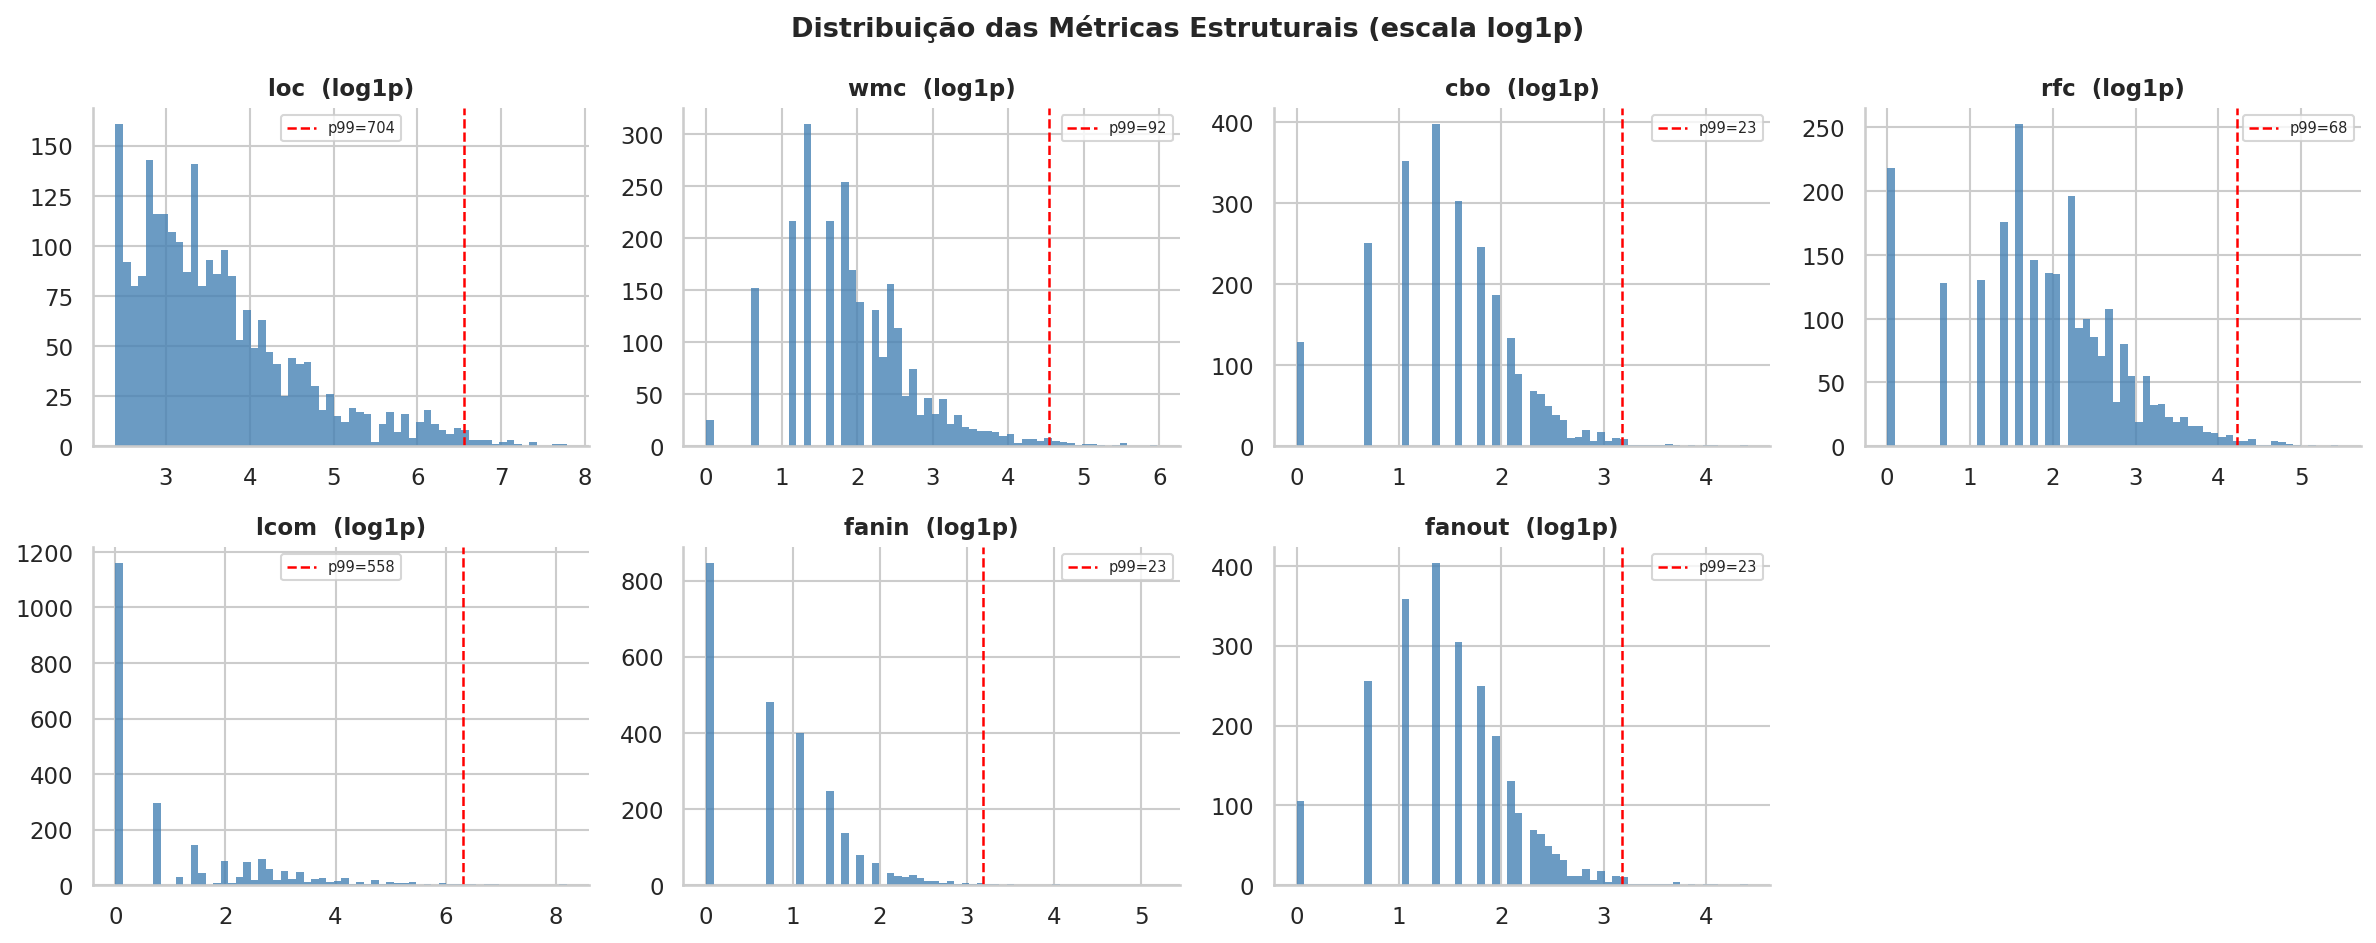


Linha vermelha = percentil 99 (cap aplicado na winsorização)


In [61]:
n = len(available_metrics)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(available_metrics):
    axes[i].hist(np.log1p(df_metrics[col]), bins=60,
                 color='steelblue', edgecolor='none', alpha=0.8)
    p99 = df_metrics[col].quantile(0.99)
    axes[i].axvline(np.log1p(p99), color='red', linestyle='--',
                    linewidth=1.2, label=f'p99={p99:.0f}')
    axes[i].set_title(f'{col}  (log1p)', fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Métricas Estruturais (escala log1p)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_metricas_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nLinha vermelha = percentil 99 (cap aplicado na winsorização)')

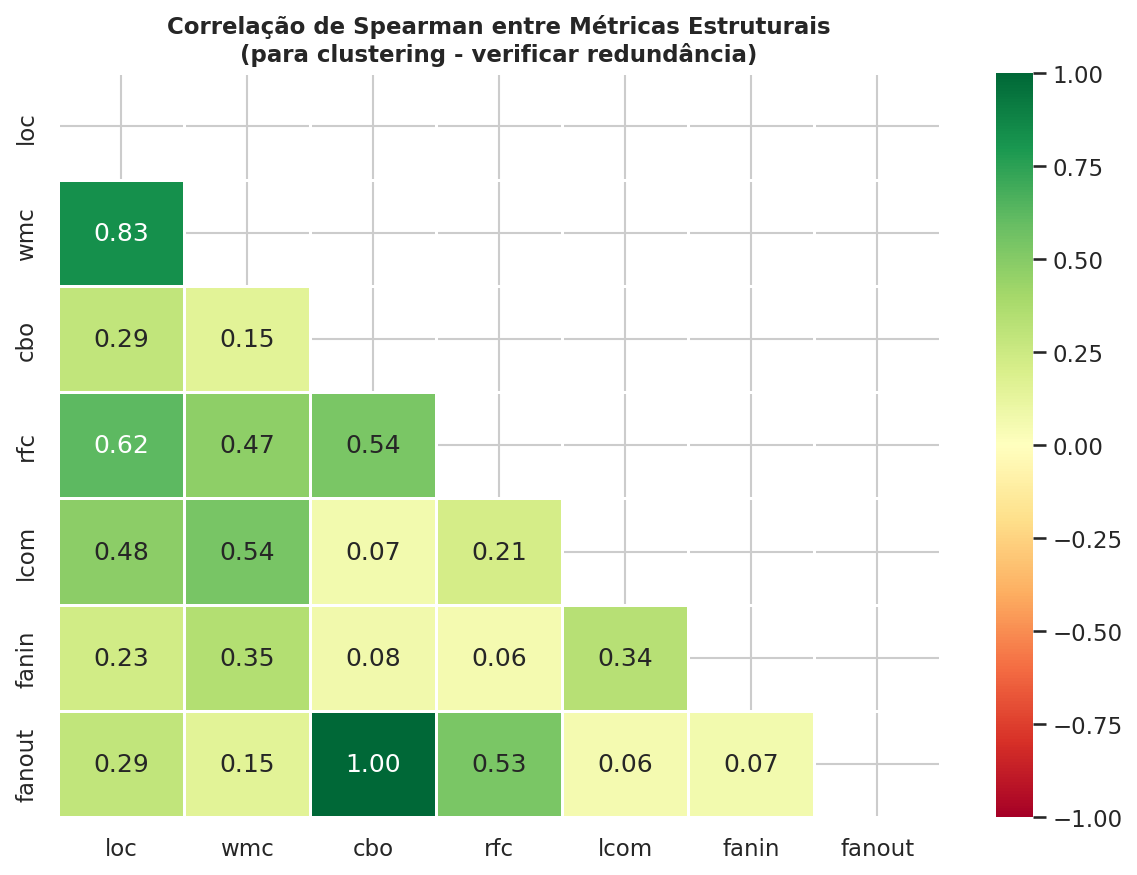

Pares com |ρ| ≥ 0.85 - considerar remover um de cada par:
   cbo ↔ fanout:  ρ = 0.996


In [62]:
corr_matrix = df_metrics.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlação de Spearman entre Métricas Estruturais\n(para clustering - verificar redundância)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_correlacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr:
    print('Pares com |ρ| ≥ 0.85 - considerar remover um de cada par:')
    for a, b, r in high_corr:
        print(f'   {a} ↔ {b}:  ρ = {r}')
else:
    print('Nenhum par altamente correlacionado - métricas suficientemente independentes.')

In [63]:
print('=== Winsorização (cap p99) ===')
df_metrics_capped = df_metrics.copy()
for col in available_metrics:
    cap = df_metrics[col].quantile(0.99)
    n_capped = (df_metrics[col] > cap).sum()
    df_metrics_capped[col] = df_metrics[col].clip(upper=cap)
    if n_capped > 0:
        print(f'  {col:<10}: {n_capped:4d} valores acima de {cap:.1f} (p99) → limitados')

print(f'\n{len(df_metrics_capped):,} entidades preservadas')

=== Winsorização (cap p99) ===
  loc       :   23 valores acima de 704.0 (p99) → limitados
  wmc       :   25 valores acima de 92.2 (p99) → limitados
  cbo       :   21 valores acima de 23.0 (p99) → limitados
  rfc       :   25 valores acima de 67.5 (p99) → limitados
  lcom      :   24 valores acima de 558.0 (p99) → limitados
  fanin     :   24 valores acima de 23.0 (p99) → limitados
  fanout    :   21 valores acima de 23.0 (p99) → limitados

2,447 entidades preservadas


In [64]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_metrics_capped)

print(f'Features no scaler : {available_metrics}')
print(f'Shape              : {X_scaled.shape}')
print(f'\nEstatísticas após MinMaxScaler (mediana ≈ 0, IQR ≈ 1):')
print(pd.DataFrame(X_scaled, columns=available_metrics)
        .describe().T[['mean','std','50%']].round(3).to_string())

print('\nColunas categóricas excluídas do scaler:')
cat_cols = [c for c in ['class', 'file', 'project', 'type'] if c in df.columns]
print(f'   {cat_cols} → mantidas apenas como metadados')

Features no scaler : ['loc', 'wmc', 'cbo', 'rfc', 'lcom', 'fanin', 'fanout']
Shape              : (2447, 7)

Estatísticas após MinMaxScaler (mediana ≈ 0, IQR ≈ 1):
         mean    std    50%
loc     0.083  0.167  0.026
wmc     0.110  0.152  0.065
cbo     0.214  0.183  0.174
rfc     0.148  0.171  0.104
lcom    0.035  0.129  0.002
fanin   0.102  0.159  0.043
fanout  0.215  0.183  0.174

Colunas categóricas excluídas do scaler:
   ['class', 'file', 'project', 'type'] → mantidas apenas como metadados


Avaliando K em 2,447 amostras (espaço: somente métricas estruturais)

  k= 2  inércia=     314.5  silhouette=0.5957
  k= 3  inércia=     245.4  silhouette=0.4121
  k= 4  inércia=     207.2  silhouette=0.4338
  k= 5  inércia=     179.4  silhouette=0.4568
  k= 6  inércia=     158.2  silhouette=0.3017
  k= 7  inércia=     142.4  silhouette=0.3205
  k= 8  inércia=     129.5  silhouette=0.3140
  k= 9  inércia=     118.0  silhouette=0.2990
  k=10  inércia=     110.3  silhouette=0.3059


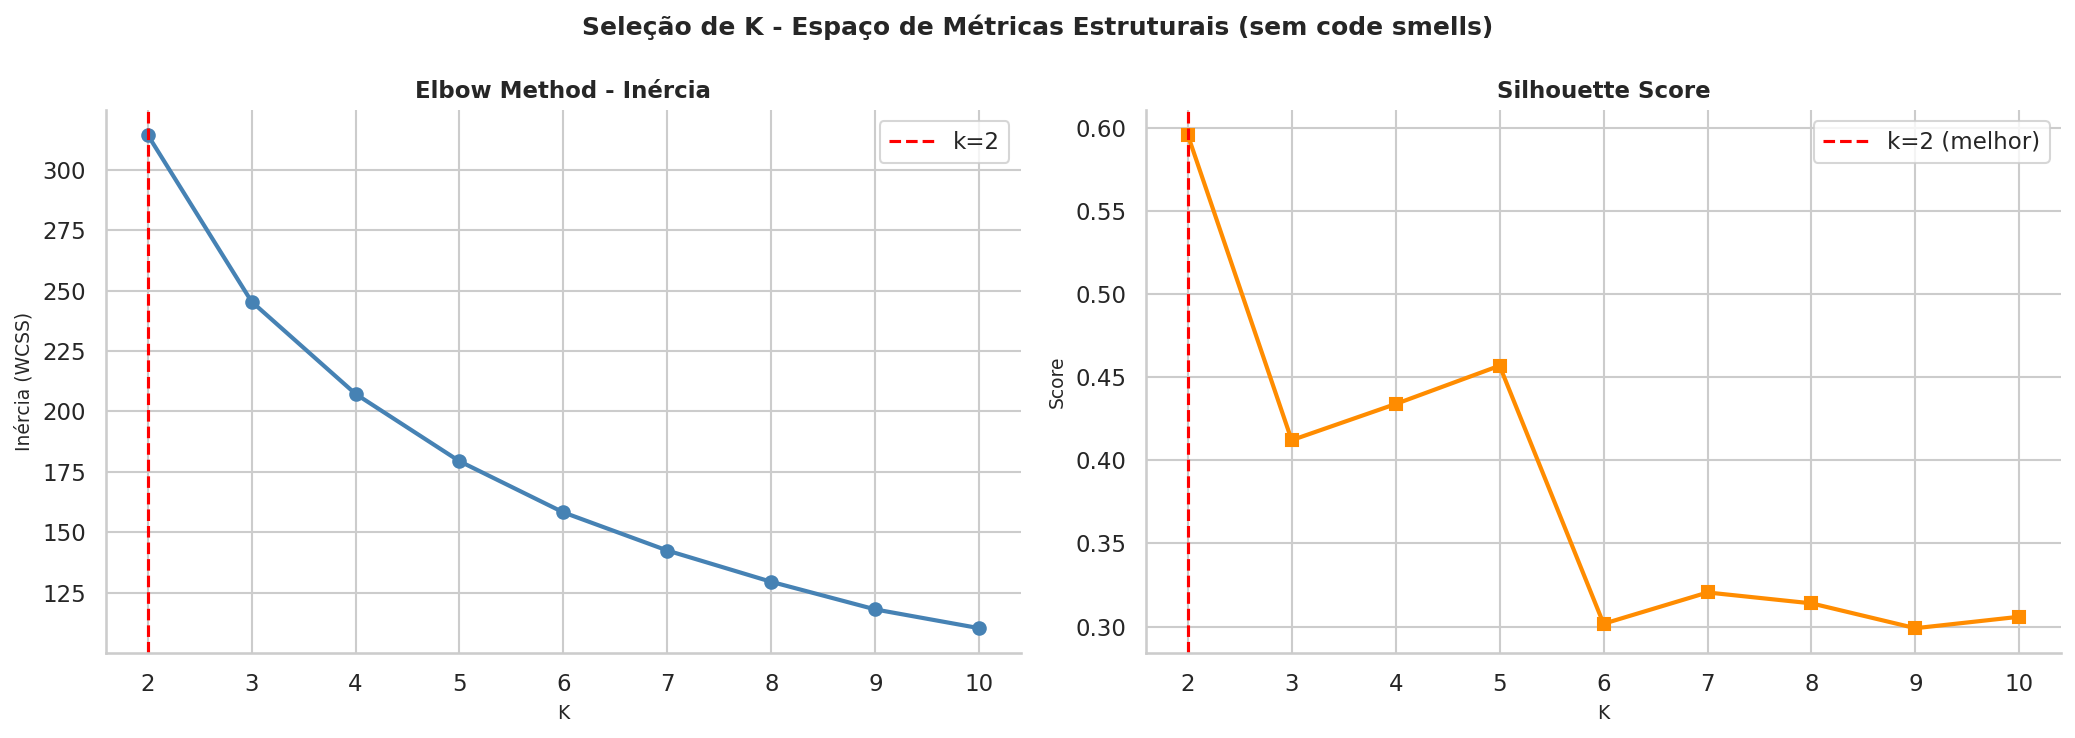


K sugerido pelo Silhouette: 2  (score=0.5957)
   Confirme visualmente o cotovelo antes de definir K_FINAL.


In [65]:
K_RANGE     = range(2, 11)
inertias    = []
silhouettes = []

n_sample = min(20_000, len(X_scaled))
rng = np.random.RandomState(SEED)
idx_sample = rng.choice(len(X_scaled), n_sample, replace=False)
X_sample = X_scaled[idx_sample]

print(f'Avaliando K em {n_sample:,} amostras (espaço: somente métricas estruturais)\n')
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15,
                max_iter=500, random_state=SEED)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, random_state=SEED)
    silhouettes.append(sil)
    print(f'  k={k:2d}  inércia={km.inertia_:>10,.1f}  silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]

axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_k_sil, color='red', linestyle='--', label=f'k={best_k_sil}')
axes[0].set_title('Elbow Method - Inércia', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_xticks(list(K_RANGE)); axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, 's-', color='darkorange', linewidth=2)
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'k={best_k_sil} (melhor)')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
axes[1].set_xticks(list(K_RANGE)); axes[1].legend()

plt.suptitle('Seleção de K - Espaço de Métricas Estruturais (sem code smells)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nK sugerido pelo Silhouette: {best_k_sil}  (score={max(silhouettes):.4f})')
print('   Confirme visualmente o cotovelo antes de definir K_FINAL.')

In [66]:
K_FINAL = 7 #Apesar do índice de Silhouette máximo ocorrer em K=2, o valor K=7 foi adotado por representar um equilíbrio entre coesão, interpretabilidade e o ponto de cotovelo observado a partir de K=6.
print(f'K_FINAL = {K_FINAL}')

K_FINAL = 7


In [67]:
# ── K-Means no espaço de métricas estruturais ────────────────────────────
kmeans = KMeans(
    n_clusters = K_FINAL,
    init       = 'k-means++',
    n_init     = 15,
    max_iter   = 500,
    random_state = SEED
)
cluster_labels = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, cluster_labels,
                              sample_size=min(10_000, len(X_scaled)),
                              random_state=SEED)
db_final  = davies_bouldin_score(X_scaled, cluster_labels)

print(f'K-Means - métricas estruturais')
print(f'   Features usadas : {available_metrics}')
print(f'   K               : {K_FINAL}')
print(f'   Inércia         : {kmeans.inertia_:,.2f}')
print(f'   Silhouette      : {sil_final:.4f}  (bom > 0.35)')
print(f'   Davies-Bouldin  : {db_final:.4f}  (melhor < 1.0)')
print(f'   Iterações       : {kmeans.n_iter_}')

print(f'\nDistribuição por cluster:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'   Cluster {c}: {n:6,d} classes ({n/len(cluster_labels)*100:.1f}%)')

# Salvar labels no dataframe de trabalho
df_work = df.copy().reset_index(drop=True)
df_work['cluster'] = cluster_labels

print('\ncluster_labels atribuídos - smells ainda NÃO foram introduzidos.')

K-Means - métricas estruturais
   Features usadas : ['loc', 'wmc', 'cbo', 'rfc', 'lcom', 'fanin', 'fanout']
   K               : 7
   Inércia         : 142.34
   Silhouette      : 0.3110  (bom > 0.35)
   Davies-Bouldin  : 1.1213  (melhor < 1.0)
   Iterações       : 27

Distribuição por cluster:
   Cluster 0:  1,141 classes (46.6%)
   Cluster 1:    115 classes (4.7%)
   Cluster 2:    256 classes (10.5%)
   Cluster 3:     81 classes (3.3%)
   Cluster 4:     40 classes (1.6%)
   Cluster 5:    761 classes (31.1%)
   Cluster 6:     53 classes (2.2%)

cluster_labels atribuídos - smells ainda NÃO foram introduzidos.


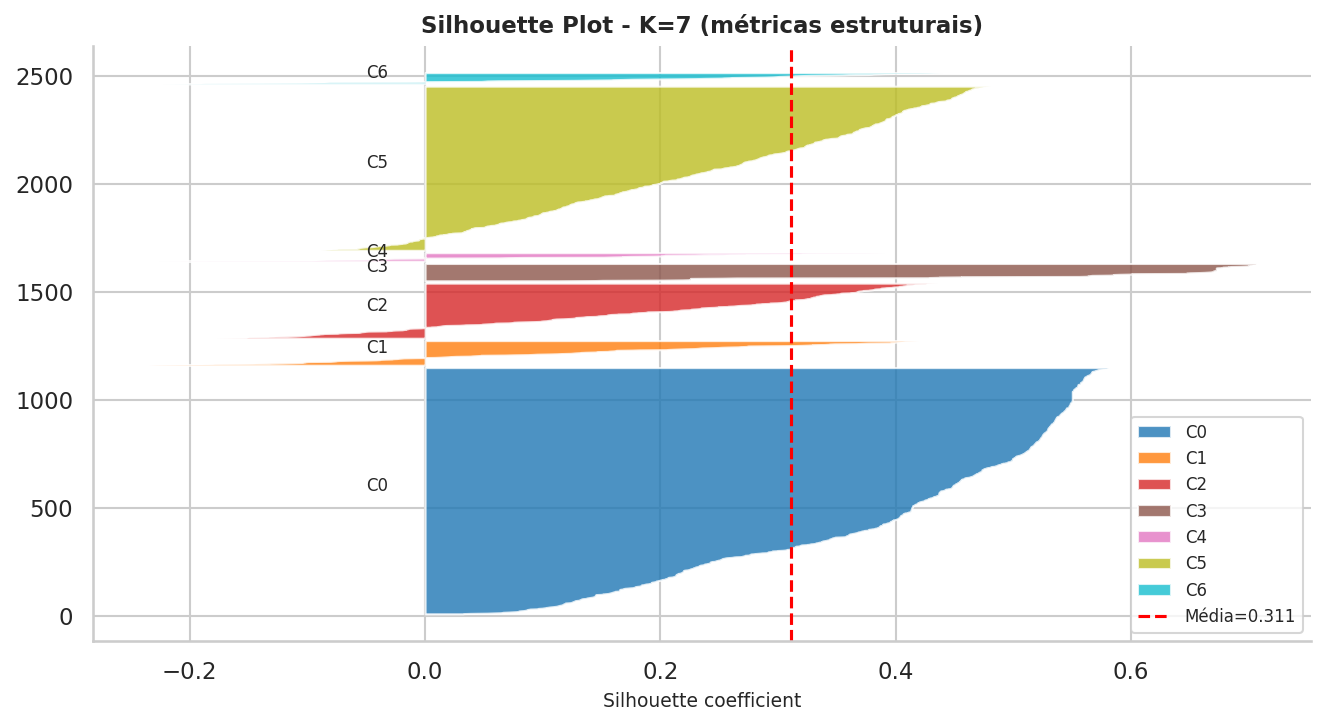

In [68]:
# ── Silhouette plot por cluster ───────────────────────────────────────────
sil_samples = silhouette_samples(X_scaled, cluster_labels)
cmap_tab    = plt.cm.get_cmap('tab10', K_FINAL)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in range(K_FINAL):
    sil_c  = np.sort(sil_samples[cluster_labels == i])
    y_upper = y_lower + len(sil_c)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_c,
                     facecolor=cmap_tab(i), alpha=0.8, label=f'C{i}')
    ax.text(-0.05, y_lower + len(sil_c)/2, f'C{i}', fontsize=8)
    y_lower = y_upper + 10

ax.axvline(sil_final, color='red', linestyle='--', label=f'Média={sil_final:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_title(f'Silhouette Plot - K={K_FINAL} (métricas estruturais)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('/content/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Calculando t-SNE em 2,447 amostras (perplexity=49)...
t-SNE concluído


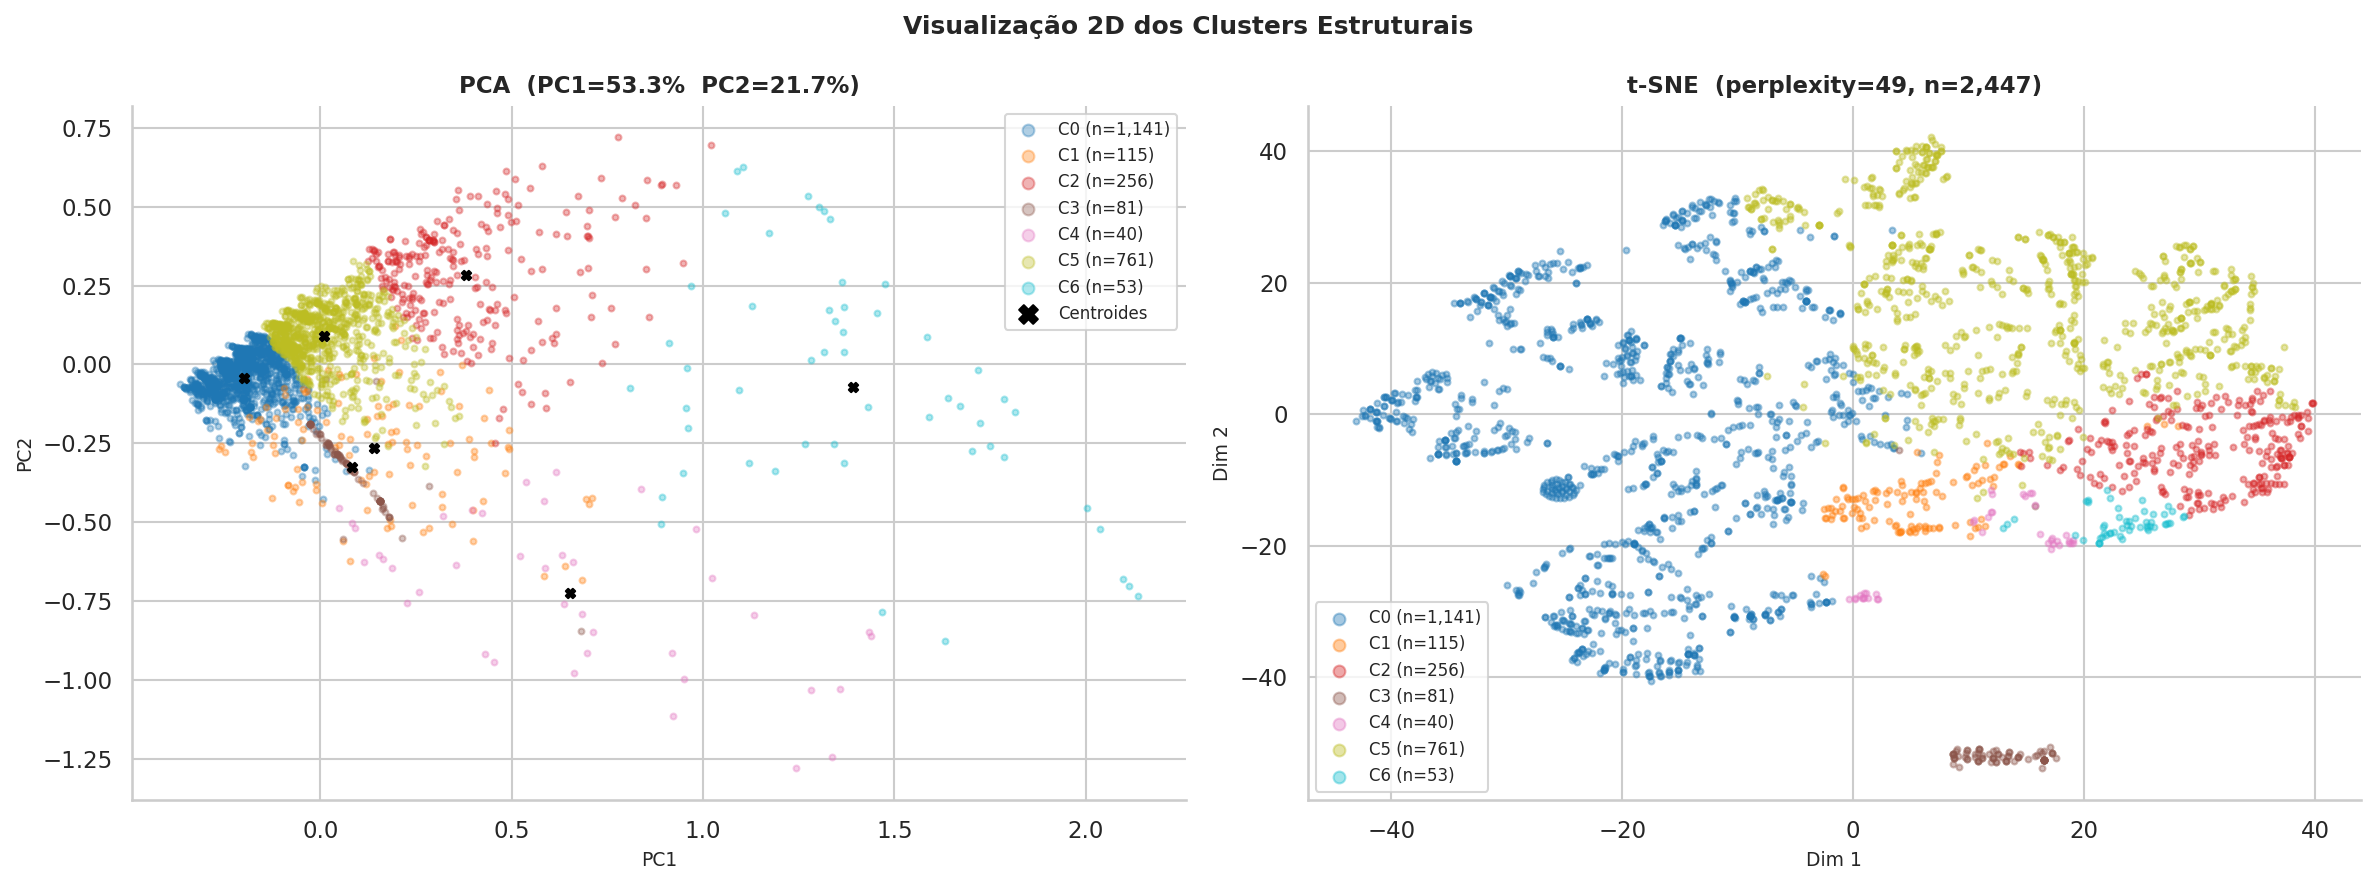


Variância explicada pelo PCA 2D: 75.1%


In [69]:
# ── PCA 2D ────────────────────────────────────────────────────────────────
pca_2d     = PCA(n_components=2, random_state=SEED)
X_pca_2d   = pca_2d.fit_transform(X_scaled)
var_exp    = pca_2d.explained_variance_ratio_

# ── t-SNE ─────────────────────────────────────────────────────────────────
# Subsample se necessário (t-SNE é O(n²))
n_tsne   = min(TSNE_SAMPLE, len(X_scaled))
idx_tsne = np.random.RandomState(SEED).choice(len(X_scaled), n_tsne, replace=False)
X_pre_tsne = PCA(n_components=min(7, X_scaled.shape[1]),
                 random_state=SEED).fit_transform(X_scaled[idx_tsne])
perp = min(50, max(30, int(np.sqrt(n_tsne))))
print(f'Calculando t-SNE em {n_tsne:,} amostras (perplexity={perp})...')
X_tsne = TSNE(n_components=2, perplexity=perp, n_iter=1000,
              learning_rate='auto', init='pca', random_state=SEED).fit_transform(X_pre_tsne)
print('t-SNE concluído')

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
for c in range(K_FINAL):
    mask = cluster_labels == c
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    s=8, alpha=0.35, color=cmap_tab(c),
                    label=f'C{c} (n={mask.sum():,})')
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                s=20, marker='X', color='black', zorder=5, label='Centroides')
axes[0].set_title(f'PCA  (PC1={var_exp[0]*100:.1f}%  PC2={var_exp[1]*100:.1f}%)',
                  fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=8)

# t-SNE
labels_tsne = cluster_labels[idx_tsne]
for c in range(K_FINAL):
    mask = labels_tsne == c
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=8, alpha=0.4, color=cmap_tab(c),
                    label=f'C{c} (n={mask.sum():,})')
axes[1].set_title(f't-SNE  (perplexity={perp}, n={n_tsne:,})', fontweight='bold')
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle('Visualização 2D dos Clusters Estruturais',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/clusters_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVariância explicada pelo PCA 2D: {sum(var_exp)*100:.1f}%')

In [70]:
df_work_metrics = df_work[available_metrics + ['cluster']].copy()

profile_median = df_work_metrics.groupby('cluster')[available_metrics].median().round(1)
profile_median['n'] = df_work_metrics.groupby('cluster').size()

print('=== Perfil Estrutural por Cluster (mediana das métricas originais) ===')
print(profile_median.to_string())

=== Perfil Estrutural por Cluster (mediana das métricas originais) ===
           loc   wmc   cbo   rfc   lcom  fanin  fanout     n
cluster                                                     
0         20.0   5.0   2.0   4.0    0.0    1.0     2.0  1141
1         79.0  15.0   4.0   9.0   21.0   11.0     4.0   115
2         57.0  10.0  11.0  17.0    0.0    1.0    11.0   256
3        471.0  12.0   3.0   4.0   13.0    1.0     3.0    81
4        278.5  72.5   4.5  27.5  484.0    5.0     4.5    40
5         31.0   5.0   6.0  10.0    0.0    1.0     6.0   761
6        342.0  54.0  22.0  62.0  140.0    6.0    22.0    53


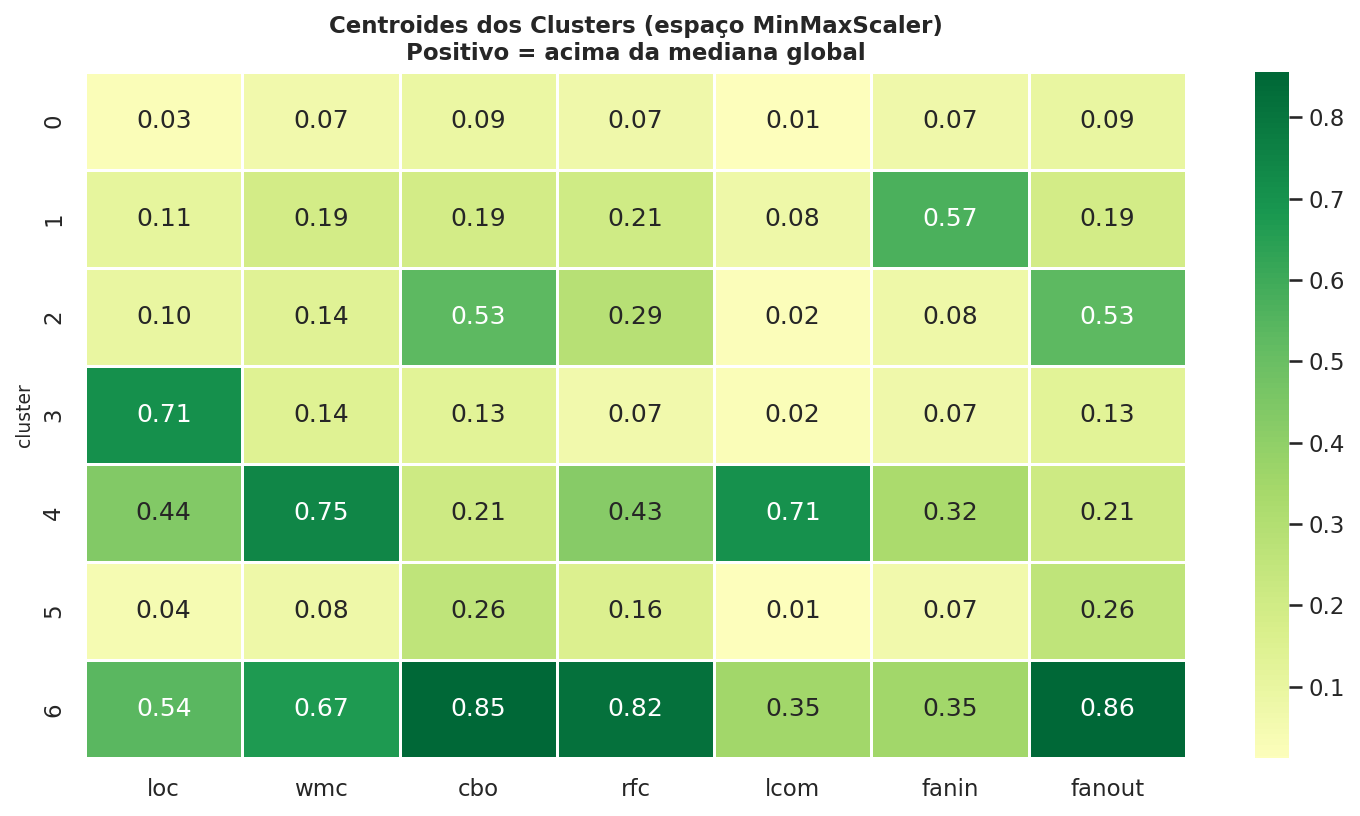

In [71]:
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=available_metrics)
centroids_df.index.name = 'cluster'

fig, ax = plt.subplots(figsize=(10, max(3, K_FINAL * 0.8)))
sns.heatmap(centroids_df, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Centroides dos Clusters (espaço MinMaxScaler)\nPositivo = acima da mediana global',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/heatmap_centroides.png', dpi=150, bbox_inches='tight')
plt.show()

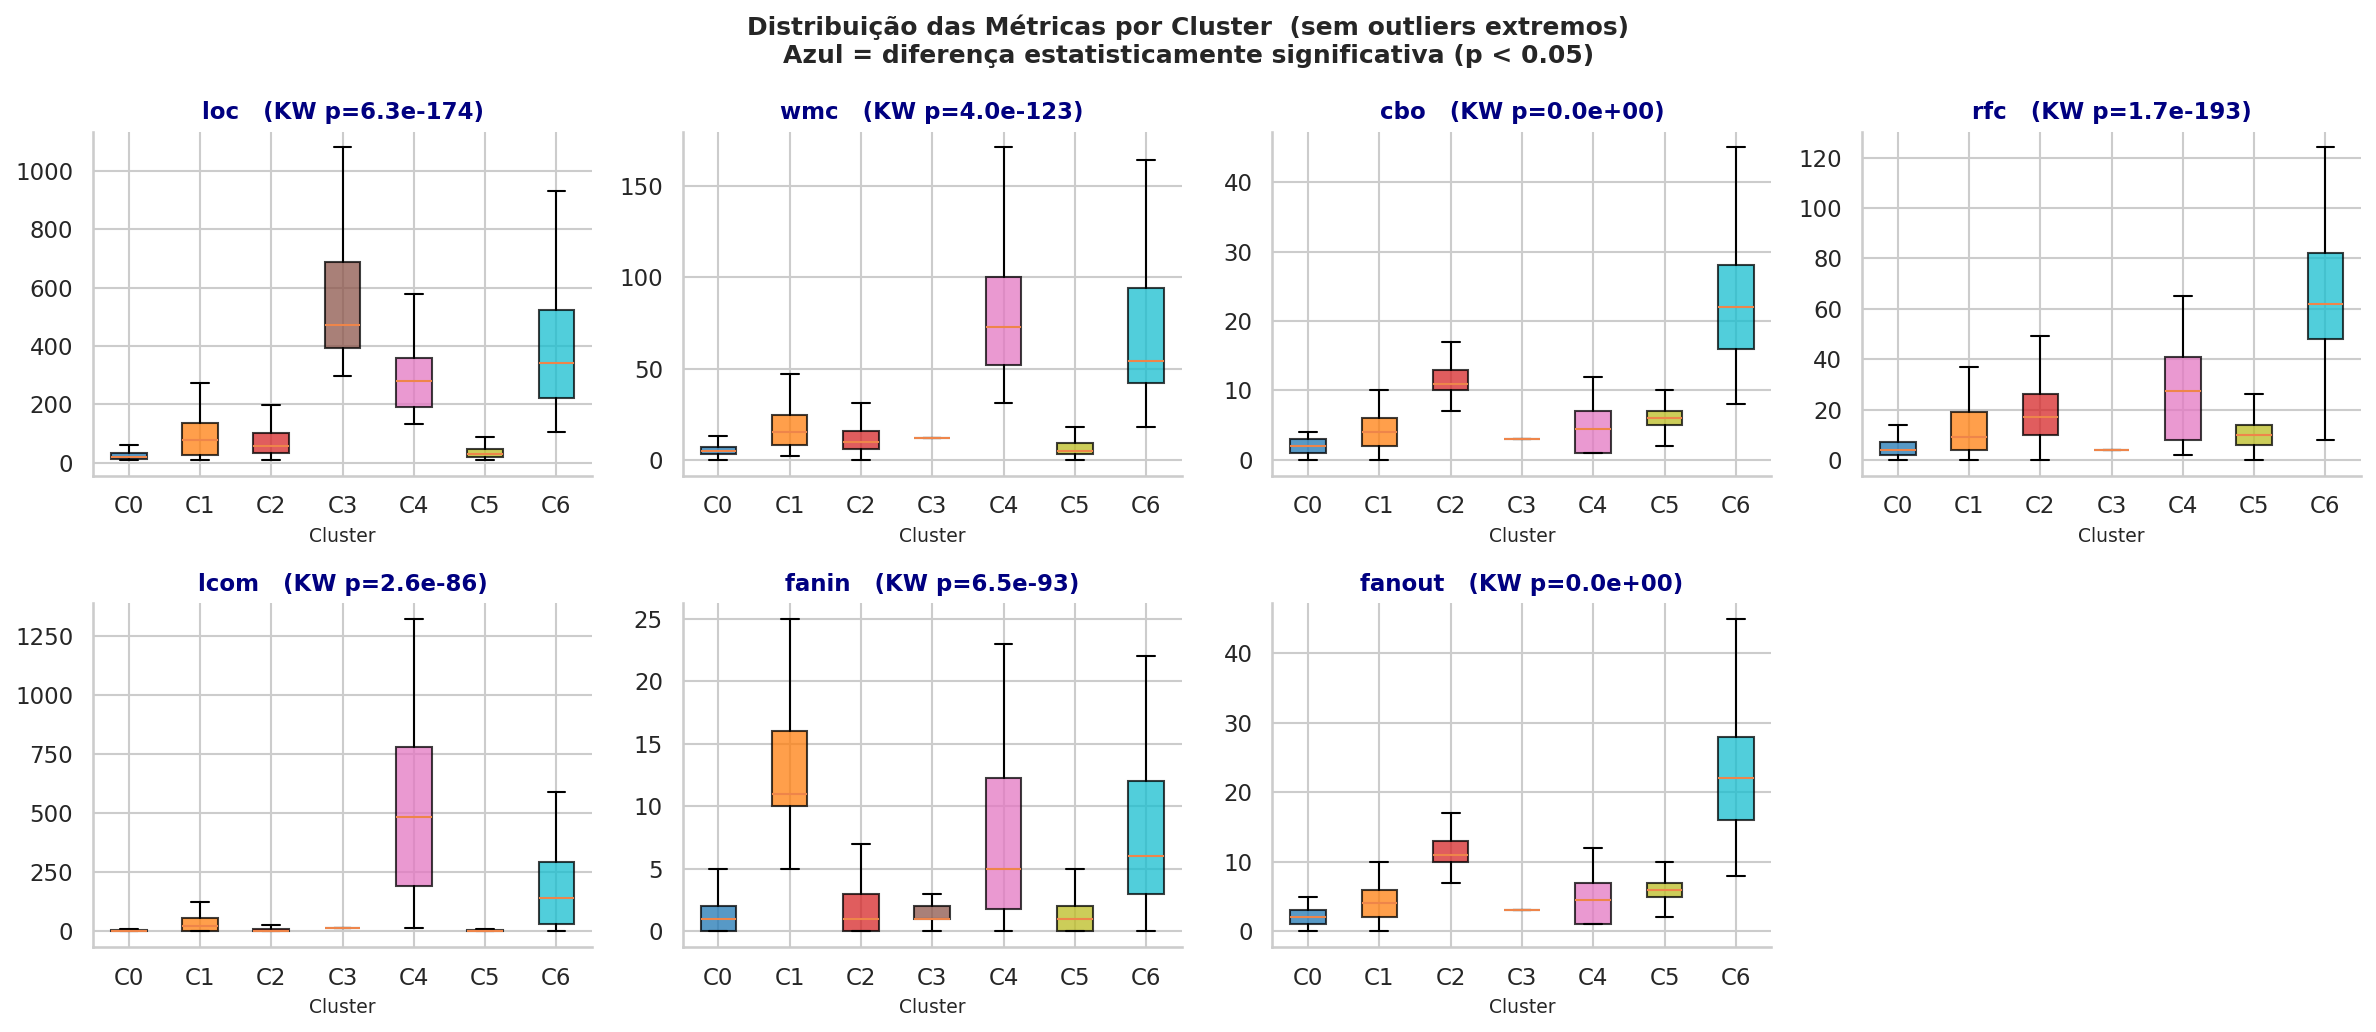

In [72]:
# Boxplots com teste Kruskal-Wallis por métrica
n_m   = len(available_metrics)
ncols = 4
nrows = (n_m + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, metric in enumerate(available_metrics):
    groups = [df_work[df_work['cluster'] == c][metric].values for c in range(K_FINAL)]
    bp = axes[i].boxplot(groups, patch_artist=True, showfliers=False)
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(cmap_tab(j))
        patch.set_alpha(0.75)
    axes[i].set_xticklabels([f'C{c}' for c in range(K_FINAL)])
    stat, p = kruskal(*groups)
    color = 'navy' if p < 0.05 else 'gray'
    axes[i].set_title(f'{metric}   (KW p={p:.1e})', fontweight='bold', color=color)
    axes[i].set_xlabel('Cluster')

for j in range(n_m, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Métricas por Cluster  (sem outliers extremos)\n'
             'Azul = diferença estatisticamente significativa (p < 0.05)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/boxplots_metricas_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
df_smells_raw = pd.read_csv(SMELLS_PATH)
df_smells_raw.columns = df_smells_raw.columns.str.strip()

smell_cols_exist = [c for c in SMELL_COLS if c in df_smells_raw.columns]
print(f'Smells disponíveis : {smell_cols_exist}')

def normalize_project(name):
    name = re.sub(r'[_-](master|develop|main|indri|mtj)(.*)?$', '',
                  str(name), flags=re.IGNORECASE)
    name = re.sub(r'^smells[_-]', '', name, flags=re.IGNORECASE)
    return name.strip().lower()

# Chaves de join
df_smells_raw['project_key'] = df_smells_raw['project_name'].apply(normalize_project)
df_smells_raw['class_key']   = df_smells_raw['class_name'].str.strip().str.split('.').str[-1].str.lower()

# Resolver duplicatas (mesma classe em linhas diferentes) com max()
df_smells_agg = (
    df_smells_raw
    .groupby(['project_key', 'class_key'])[smell_cols_exist]
    .max()
    .reset_index()
)

# Chaves no dataset clusterizado
df_work['project_key'] = df_work['project'].apply(normalize_project) if 'project' in df_work.columns else 'unknown'
df_work['class_key']   = df_work['class'].str.strip().str.split('.').str[-1].str.lower() if 'class' in df_work.columns else 'unknown'

# LEFT JOIN - mantém todas as entidades clusterizadas
df_final = pd.merge(df_work, df_smells_agg,
                    on=['project_key', 'class_key'], how='left')

# Classes sem match -> ausência de smell (0)
df_final[smell_cols_exist] = df_final[smell_cols_exist].fillna(0).astype(int)
df_final['has_smell']  = (df_final[smell_cols_exist].sum(axis=1) > 0).astype(int)
df_final['n_smells']   = df_final[smell_cols_exist].sum(axis=1)

n_total   = len(df_final)
n_matched = df_final['has_smell'].sum()
print(f'\nShape após merge : {df_final.shape}')
print(f'Com smell        : {n_matched:,} ({n_matched/n_total*100:.1f}%)')
print(f'Sem smell        : {n_total-n_matched:,} ({(n_total-n_matched)/n_total*100:.1f}%)')

Smells disponíveis : ['BrainMethod', 'ClassDataShouldBePrivate', 'ComplexClass', 'DataClass', 'DispersedCoupling', 'FeatureEnvy', 'GodClass', 'IntensiveCoupling', 'LazyClass', 'LongMethod', 'LongParameterList', 'MessageChain', 'RefusedBequest', 'ShotgunSurgery', 'SpaghettiCode', 'SpeculativeGenerality']

Shape após merge : (2447, 74)
Com smell        : 814 (33.3%)
Sem smell        : 1,633 (66.7%)


In [74]:
# Incidência de smells por cluster (% de classes afetadas)
smell_by_cluster = (
    df_final.groupby('cluster')[smell_cols_exist]
    .mean().mul(100).round(1)
)
smell_by_cluster['n_classes'] = df_final.groupby('cluster').size()
smell_by_cluster['any_smell%'] = (
    df_final.groupby('cluster')['has_smell'].mean().mul(100).round(1)
)

print('=== Incidência de Code Smells por Cluster (% classes afetadas) ===')
print(smell_by_cluster.to_string())

=== Incidência de Code Smells por Cluster (% classes afetadas) ===
         BrainMethod  ClassDataShouldBePrivate  ComplexClass  DataClass  DispersedCoupling  FeatureEnvy  GodClass  IntensiveCoupling  LazyClass  LongMethod  LongParameterList  MessageChain  RefusedBequest  ShotgunSurgery  SpaghettiCode  SpeculativeGenerality  n_classes  any_smell%
cluster                                                                                                                                                                                                                                                                                  
0                0.1                       1.8           0.8        6.1                0.0          6.9       0.0                0.0       10.2         5.4                8.3           7.3             1.8             0.0            0.1                    2.7       1141        28.3
1                0.0                       2.6           1.7        2.6                

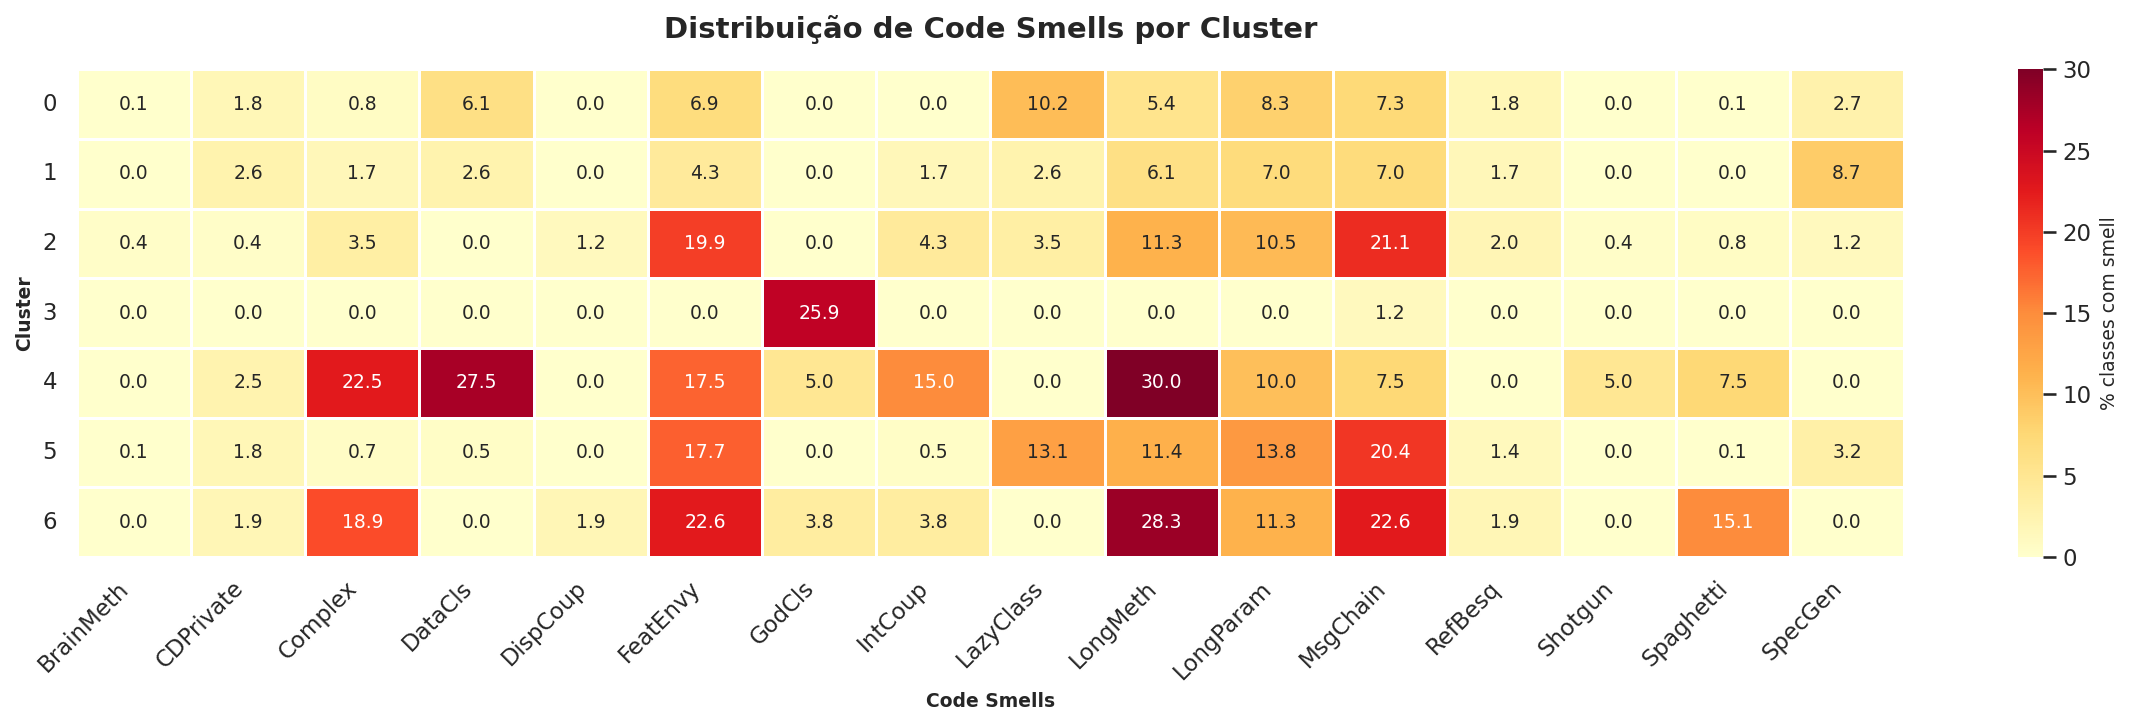

In [75]:

smell_short_cols = [
    SMELL_SHORT.get(s, s)
    for s in smell_cols_exist
]

# dados
heat_data = smell_by_cluster[smell_cols_exist].copy()

# renomear colunas
heat_data.columns = smell_short_cols

# inverter orientação
heat_data = heat_data.copy()

# Plot

fig, ax = plt.subplots(
    figsize=(16, 5)
)

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': '% classes com smell'
    },
    annot_kws={
        'size': 9
    },
    ax=ax
)

# labels
ax.set_xlabel(
    'Code Smells',
    fontweight='bold'
)

ax.set_ylabel(
    'Cluster',
    fontweight='bold'
)

# título
ax.set_title(
    'Distribuição de Code Smells por Cluster',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# rotação labels
plt.xticks(
    rotation=45,
    ha='right'
)

plt.yticks(
    rotation=0
)

# layout
plt.tight_layout()

# salvar
plt.savefig(
    '/content/heatmap_smells_cluster.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

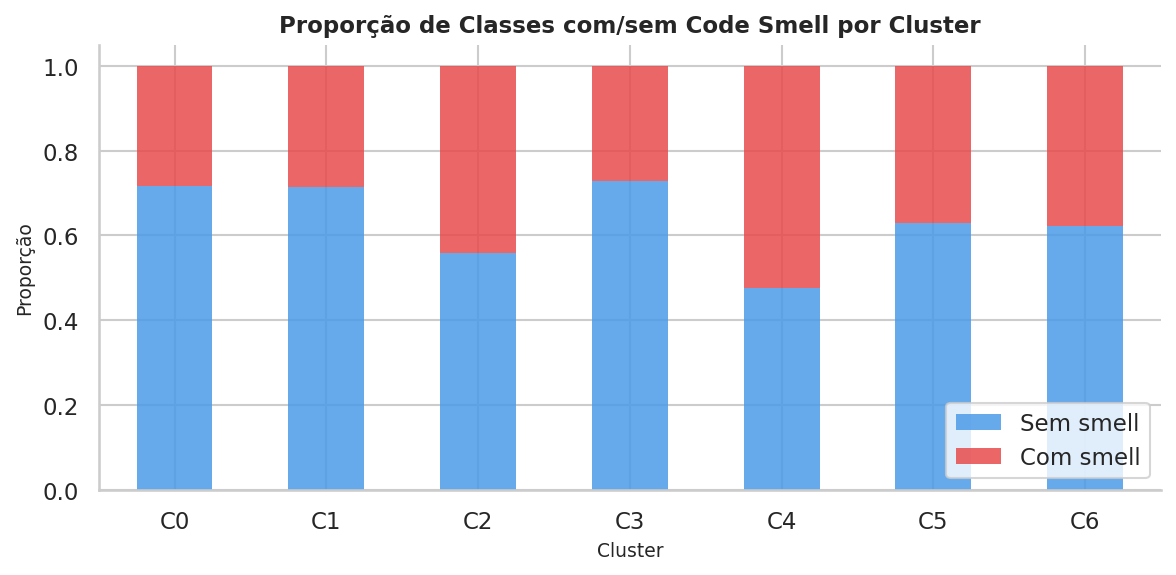

In [76]:
# Proporção com/sem smell por cluster
props = df_final.groupby('cluster')['has_smell'].value_counts(normalize=True).unstack().fillna(0)
props.columns = ['Sem smell', 'Com smell']

fig, ax = plt.subplots(figsize=(8, 4))
props.plot(kind='bar', stacked=True, ax=ax,
           color=['#4C9BE8', '#E84C4C'], edgecolor='none', alpha=0.85)
ax.set_xlabel('Cluster'); ax.set_ylabel('Proporção')
ax.set_title('Proporção de Classes com/sem Code Smell por Cluster', fontweight='bold')
ax.set_xticklabels([f'C{c}' for c in props.index], rotation=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/prop_smell_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# Kruskal-Wallis: diferença de incidência de smell entre clusters
print('=== Kruskal-Wallis - Significância das Diferenças entre Clusters ===')
print(f'{"Smell":<35} {"H":>8} {"p-value":>12} {"Sig?":>8}')
print('-' * 68)
for smell in smell_cols_exist:
    groups = [df_final[df_final['cluster'] == c][smell].values
              for c in range(K_FINAL)]
    if sum(g.sum() for g in groups) > 0:
        stat, p = kruskal(*groups)
        sig = 'Sim' if p < 0.05 else 'Não'
        print(f'{smell:<35} {stat:>8.2f} {p:>12.2e} {sig:>8}')

=== Kruskal-Wallis - Significância das Diferenças entre Clusters ===
Smell                                      H      p-value     Sig?
--------------------------------------------------------------------
BrainMethod                             1.97     9.22e-01      Não
ClassDataShouldBePrivate                5.04     5.38e-01      Não
ComplexClass                          202.41     5.81e-41      Sim
DataClass                             122.65     4.51e-24      Sim
DispersedCoupling                      29.08     5.86e-05      Sim
FeatureEnvy                            92.19     1.06e-17      Sim
GodClass                              530.28    2.51e-111      Sim
IntensiveCoupling                     123.42     3.12e-24      Sim
LazyClass                              48.32     1.02e-08      Sim
LongMethod                             82.17     1.27e-15      Sim
LongParameterList                      26.08     2.15e-04      Sim
MessageChain                          104.01     3.65e-20 

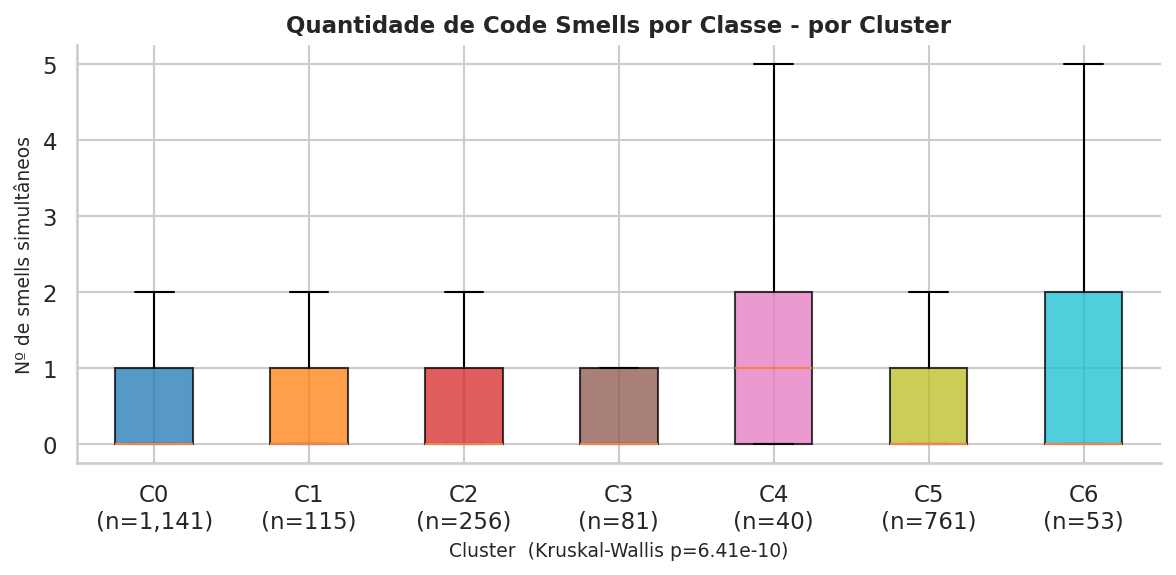


Média de smells simultâneos por cluster:
cluster
0    0.516
1    0.461
2    0.805
3    0.272
4    1.500
5    0.849
6    1.321


In [78]:
# Número de smells simultâneos por cluster
fig, ax = plt.subplots(figsize=(8, 4))
groups = [df_final[df_final['cluster'] == c]['n_smells'].values for c in range(K_FINAL)]
bp = ax.boxplot(groups, patch_artist=True, showfliers=False)
for j, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap_tab(j))
    patch.set_alpha(0.75)
ax.set_xticklabels([f'C{c}\n(n={len(groups[c]):,})' for c in range(K_FINAL)])
ax.set_ylabel('Nº de smells simultâneos')
ax.set_title('Quantidade de Code Smells por Classe - por Cluster', fontweight='bold')
stat, p = kruskal(*groups)
ax.set_xlabel(f'Cluster  (Kruskal-Wallis p={p:.2e})')
plt.tight_layout()
plt.savefig('/content/n_smells_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMédia de smells simultâneos por cluster:')
print(df_final.groupby('cluster')['n_smells'].mean().round(3).to_string())

In [79]:
# Tabela de síntese final

summary = profile_median.copy()

summary['any_smell%'] = (
    df_final
    .groupby('cluster')['has_smell']
    .mean()
    .mul(100)
    .round(1)
)

summary['avg_n_smells'] = (
    df_final
    .groupby('cluster')['n_smells']
    .mean()
    .round(2)
)

# Perfil de smells

smell_profile = (
    df_final
    .groupby('cluster')[smell_cols_exist]
    .mean()
    .mul(100)
)

# Dataset de referência

dataset = df_metrics

# thresholds globais
loc_high  = dataset['loc'].quantile(0.75)
wmc_high  = dataset['wmc'].quantile(0.75)
cbo_high  = dataset['cbo'].quantile(0.75)
lcom_high = dataset['lcom'].quantile(0.75)

# Impressão

print('=== SÍNTESE FINAL DOS CLUSTERS ===')
print(summary.to_string())

print('\n' + '='*65)
print('ROTULAÇÃO DAS MÉTRICAS CLUSTERIZADAS')
print('='*65)

# Loop clusters

for c in range(K_FINAL):

    row = summary.loc[c]

    loc   = row.get('loc', 0)
    wmc   = row.get('wmc', 0)
    cbo   = row.get('cbo', 0)
    lcom  = row.get('lcom', 0)

    # Labels estruturais

    labels = []

    if loc > loc_high and wmc > wmc_high:
        labels.append('Grandes/Complexas')

    if cbo > cbo_high:
        labels.append('Alto Acoplamento')

    if lcom > lcom_high:
        labels.append('Baixa Coesão')

    if not labels:
        labels.append('Complexidade Moderada')

    label = ' + '.join(labels)

    # Smells relevantes

    cluster_smells = smell_profile.loc[c]

    strong_smells = cluster_smells[
        cluster_smells > 20
    ].index.tolist()

    if not strong_smells:
        strong_smells = ['Baixa incidência de smells']

    # Output
    print(f'\nCluster {c}: {label}')

    print(
        f'  loc={loc:.1f}, '
        f'wmc={wmc:.1f}, '
        f'cbo={cbo:.1f}, '
        f'lcom={lcom:.1f}'
    )

    print(
        f'  smells relevantes: '
        f'{", ".join(strong_smells)}'
    )

    print(
        f'  any_smell%={row["any_smell%"]:.1f}%'
    )

=== SÍNTESE FINAL DOS CLUSTERS ===
           loc   wmc   cbo   rfc   lcom  fanin  fanout     n  any_smell%  avg_n_smells
cluster                                                                               
0         20.0   5.0   2.0   4.0    0.0    1.0     2.0  1141        28.3          0.52
1         79.0  15.0   4.0   9.0   21.0   11.0     4.0   115        28.7          0.46
2         57.0  10.0  11.0  17.0    0.0    1.0    11.0   256        44.1          0.80
3        471.0  12.0   3.0   4.0   13.0    1.0     3.0    81        27.2          0.27
4        278.5  72.5   4.5  27.5  484.0    5.0     4.5    40        52.5          1.50
5         31.0   5.0   6.0  10.0    0.0    1.0     6.0   761        37.1          0.85
6        342.0  54.0  22.0  62.0  140.0    6.0    22.0    53        37.7          1.32

ROTULAÇÃO DAS MÉTRICAS CLUSTERIZADAS

Cluster 0: Complexidade Moderada
  loc=20.0, wmc=5.0, cbo=2.0, lcom=0.0
  smells relevantes: Baixa incidência de smells
  any_smell%=28.3%

Clu

In [80]:
# Remove colunas auxiliares de join
export_cols = [c for c in df_final.columns
               if c not in ['project_key', 'class_key']]
df_export = df_final[export_cols].copy()

df_export.to_csv(OUTPUT_PATH, index=False)

print(f'Dataset exportado : {OUTPUT_PATH}')
print(f'   Linhas    : {df_export.shape[0]:,}')
print(f'   Colunas   : {df_export.shape[1]}')
print('\nColunas adicionadas:')
print('  cluster    → label K-Means (baseado em métricas estruturais)')
print('  has_smell  → 1 se qualquer smell presente')
print('  n_smells   → quantidade de smells simultâneos')

Dataset exportado : /content/dataset_clusterizado.csv
   Linhas    : 2,447
   Colunas   : 72

Colunas adicionadas:
  cluster    → label K-Means (baseado em métricas estruturais)
  has_smell  → 1 se qualquer smell presente
  n_smells   → quantidade de smells simultâneos


In [81]:
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=METRIC_COLS
)

print(centroids_original)

          loc        wmc        cbo        rfc        lcom      fanin  \
0   28.684441   6.172203   2.122378   4.686189    7.450175   1.577797   
1   86.165217  17.773913   4.417391  13.943826   42.669565  13.165217   
2   76.847656  12.492188  12.292969  19.259922    9.250000   1.761719   
3  503.395062  13.283951   3.061728   4.419753   12.234568   1.691358   
4  314.025000  68.694000   4.875000  28.779000  394.375000   7.425000   
5   39.319261   7.180739   5.897098  10.654354    6.649077   1.498681   
6  383.528302  61.759245  19.622642  55.212453  195.433962   8.037736   

      fanout  
0   2.180070  
1   4.417391  
2  12.300781  
3   3.061728  
4   4.875000  
5   5.919525  
6  19.679245  
